# 01 - Setup & EDA - Telco Customer Churn

## Introduction

**Contexte.** TelcoWave, opérateur télécom (mobile + fibre) en Europe, veut réduire le churn
(résiliations) au prochain trimestre via un programme de rétention ciblé (appels, remises,
changement d'offre) sous **budget marketing limité**. L'objectif final du projet est un modèle
de **scoring** estimant la probabilité de churn de chaque client, pour prioriser les actions
sur les plus à risque.

**Ce notebook (Étape 1 — EDA).** Avant toute modélisation, on cherche à *comprendre* le jeu de
données : contrôler sa qualité, décrire ses distributions, relier chaque variable à la cible
`Churn`, et **figer le protocole d'évaluation** qui servira de référence aux Phases 2 (baseline)
et 3 (finetuning).

**Jeu de données.** Extrait anonymisé (un enregistrement par client) : 7043 clients × 21 colonnes
— démographie, services souscrits, contrat, facturation. Cible : `Churn` (Yes/No).

## Sommaire

1. **Chargement et premier coup d'œil** — dimensions, types, statistiques descriptives.
2. **Dictionnaire de données** — définition métier, type, exemple et modalités par colonne.
3. **Contrôles qualité** — valeurs manquantes (piège `TotalCharges`), doublons, cohérences, modalités.
4. **Exploration de la cible** — taux de churn global et par segments, distributions, corrélations.
5. **Protocole d'évaluation** — split stratifié, métriques, gestion du déséquilibre.
6. **Synthèse** — conclusions clés et préparation de la modélisation.

In [76]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

from src.config import DATA_RAW, RANDOM_STATE, TARGET

## Section 1: Chargement et premiere inspection

In [77]:
df = pd.read_csv(DATA_RAW)
print("Dimensions :", df.shape)
df.head()

Dimensions : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Section 2: Dictionnaire de données

Pour chaque colonne : définition métier, type, exemple, nombre de modalités.
Points d'attention repérés : `SeniorCitizen` en 0/1 (les autres binaires sont en Yes/No),
`TotalCharges` lu en texte, et la 3ᵉ modalité « No internet/phone service » sur plusieurs colonnes service.

In [79]:
definitions = {
    "customerID": "Identifiant unique du client",
    "gender": "Sexe du client (Female/Male)",
    "SeniorCitizen": "Client senior (binaire encodé en 0/1)",
    "Partner": "Le client a un(e) conjoint(e) (Yes/No)",
    "Dependents": "Le client a des personnes à charge (Yes/No)",
    "tenure": "Ancienneté du client en mois",
    "PhoneService": "Souscription au service téléphonique (Yes/No)",
    "MultipleLines": "Plusieurs lignes téléphoniques (Yes/No/No phone service)",
    "InternetService": "Type de connexion internet (DSL/Fiber optic/No)",
    "OnlineSecurity": "Option sécurité en ligne (Yes/No/No internet service)",
    "OnlineBackup": "Option sauvegarde en ligne (Yes/No/No internet service)",
    "DeviceProtection": "Option protection des appareils (Yes/No/No internet service)",
    "TechSupport": "Option support technique (Yes/No/No internet service)",
    "StreamingTV": "Option streaming TV (Yes/No/No internet service)",
    "StreamingMovies": "Option streaming films (Yes/No/No internet service)",
    "Contract": "Type de contrat (Month-to-month/One year/Two year)",
    "PaperlessBilling": "Facturation dématérialisée (Yes/No)",
    "PaymentMethod": "Moyen de paiement (4 modalités)",
    "MonthlyCharges": "Montant facturé mensuellement (€)",
    "TotalCharges": "Montant total facturé depuis le début (€) — LU EN TEXTE",
    "Churn": "CIBLE : le client a résilié (Yes/No)",
}

rows = []
for col in df.columns:
    s = df[col]
    rows.append({
        "colonne": col,
        "définition": definitions[col],
        "type_pandas": str(s.dtype),
        "exemple": s.dropna().iloc[0],
        "nb_modalités": s.nunique(),
        "nb_manquants": s.isna().sum(),
    })

data_dico = pd.DataFrame(rows)
data_dico

,colonne,définition,type_pandas,exemple,nb_modalités,nb_manquants
0,customerID,Identifiant unique du client,object,7590-VHVEG,7043,0
1,gender,Sexe du client (Female/Male),object,Female,2,0
2,SeniorCitizen,Client senior (binaire encodé en 0/1),int64,0,2,0
3,Partner,Le client a un(e) conjoint(e) (Yes/No),object,Yes,2,0
4,Dependents,Le client a des personnes à charge (Yes/No),object,No,2,0
5,tenure,Ancienneté du client en mois,int64,1,73,0
6,PhoneService,Souscription au service téléphonique (Yes/No),object,No,2,0
7,MultipleLines,Plusieurs lignes téléphoniques (Yes/No/No phon...,object,No phone service,3,0
8,InternetService,Type de connexion internet (DSL/Fiber optic/No),object,DSL,3,0
9,OnlineSecurity,Option sécurité en ligne (Yes/No/No internet s...,object,No,3,0


In [80]:
# Export du dataframe en csv dans reports/
(ROOT / "reports").mkdir(exist_ok=True)
data_dico.to_csv(ROOT / "reports" / "data_dictionary.csv", index=False, encoding="utf-8-sig")

## Section 3: Contrôles qualité

Vérification de la fiabilité des données : valeurs manquantes (le piège `TotalCharges`),
conversion de type, doublons, cohérences et valeurs aberrantes, modalités catégorielles.

In [81]:
print("NaN détectés par pandas :", df.isna().sum().sum())

# Création d'un mask pour afficher seulement les ligne avec TotalCharges = ""
mask_blank = df["TotalCharges"].str.strip() == ""
print("Valeurs vides (espaces) dans TotalCharges :", mask_blank.sum())

print("tenure de ces lignes :", sorted(df.loc[mask_blank, "tenure"].unique()))
df.loc[mask_blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

NaN détectés par pandas : 0
Valeurs vides (espaces) dans TotalCharges : 11
tenure de ces lignes : [np.int64(0)]


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Constat :** les 11 « manquants » réels de `TotalCharges` sont des espaces, pas des `NaN`.
Tous correspondent à `tenure = 0` (clients jamais facturés) et tous ont `Churn = No`.
**Décision :** convertir en numérique, imputer ces 11 valeurs à **0** ,
et créer un drapeau `totalcharges_was_missing`.
Le traitement final ira dans la pipeline.

### 3.2 - Conversion de type

In [82]:
# Conversion des 11 espaces en NaN
total_charges_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("NaN après conversion :", total_charges_num.isna().sum())

# Vérifications avec les lignes précédentes
if (total_charges_num.isna() == mask_blank).all():
    print("OK : les NaN correspondent bien aux espaces blancs")
else:
    print("PROBLÈME : des NaN inattendus ont été introduits")

NaN après conversion : 11
OK : les NaN correspondent bien aux espaces blancs


### 3.3 - Doublons

In [83]:
print("Lignes entièrement dupliquées :", df.duplicated().sum())
print("customerID dupliqués :", df["customerID"].duplicated().sum())
print("customerID est unique :", df["customerID"].is_unique)

Lignes entièrement dupliquées : 0
customerID dupliqués : 0
customerID est unique : True


### 3.4 - Cohérences et valeurs aberrantes

In [84]:
print("Min / Max :")
print("tenure          :", df["tenure"].min(), "/", df["tenure"].max(), "mois")
print("MonthlyCharges  :", df["MonthlyCharges"].min(), "/", df["MonthlyCharges"].max(), "€")
print("TotalCharges    :", round(total_charges_num.min(), 2), "/", round(total_charges_num.max(), 2), "€")
print()
# Cohérence croisée : TotalCharges = tenure × MonthlyCharges (ordre de grandeur)
ecart = (total_charges_num - df["tenure"] * df["MonthlyCharges"]).abs()
print("Écart médian |TotalCharges − tenure×MonthlyCharges| :", round(ecart.median(), 2), "€")

Min / Max :
tenure          : 0 / 72 mois
MonthlyCharges  : 18.25 / 118.75 €
TotalCharges    : 18.8 / 8684.8 €

Écart médian |TotalCharges − tenure×MonthlyCharges| : 28.65 €


### 3.5 - Modalités catégorielles

In [85]:
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "TotalCharges"])
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64 

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64 

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet ser

## Section 4: Exploration de la cible

Taux de churn global puis croisé avec les variables catégorielles et numériques,
pour identifier les segments à risque. Figures sauvegardées dans `reports/figures/`.

In [86]:
# Cible numérique pour les agrégations + version numérique de TotalCharges
df["churn_binary"] = (df[TARGET] == "Yes").astype(int)
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

### 4.1 - Taux de churn global

Taux de churn global : 26.5%
Churn
No     5174
Yes    1869
Name: count, dtype: int64


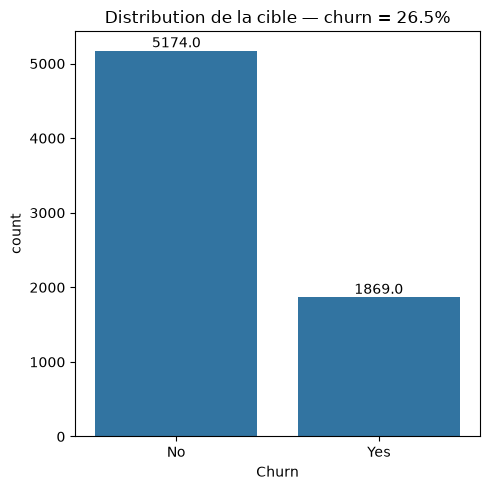

In [87]:
taux = df["churn_binary"].mean()
print(f"Taux de churn global : {taux:.1%}")
print(df[TARGET].value_counts())

fig, ax = plt.subplots(figsize=(5, 5))
sns.countplot(data=df, x=TARGET, order=["No", "Yes"], ax=ax)
ax.set_title(f"Distribution de la cible — churn = {taux:.1%}")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_global.png", dpi=130)
plt.show()

**Déséquilibre modéré** (~26,5 % de positifs) : ni équilibré, ni extrême.
On privilégiera des métriques adaptées (PR-AUC, recall@K) et `class_weight="balanced"`
plutôt qu'un rééchantillonnage agressif.

### 4.2 - Churn par variable catégorielle

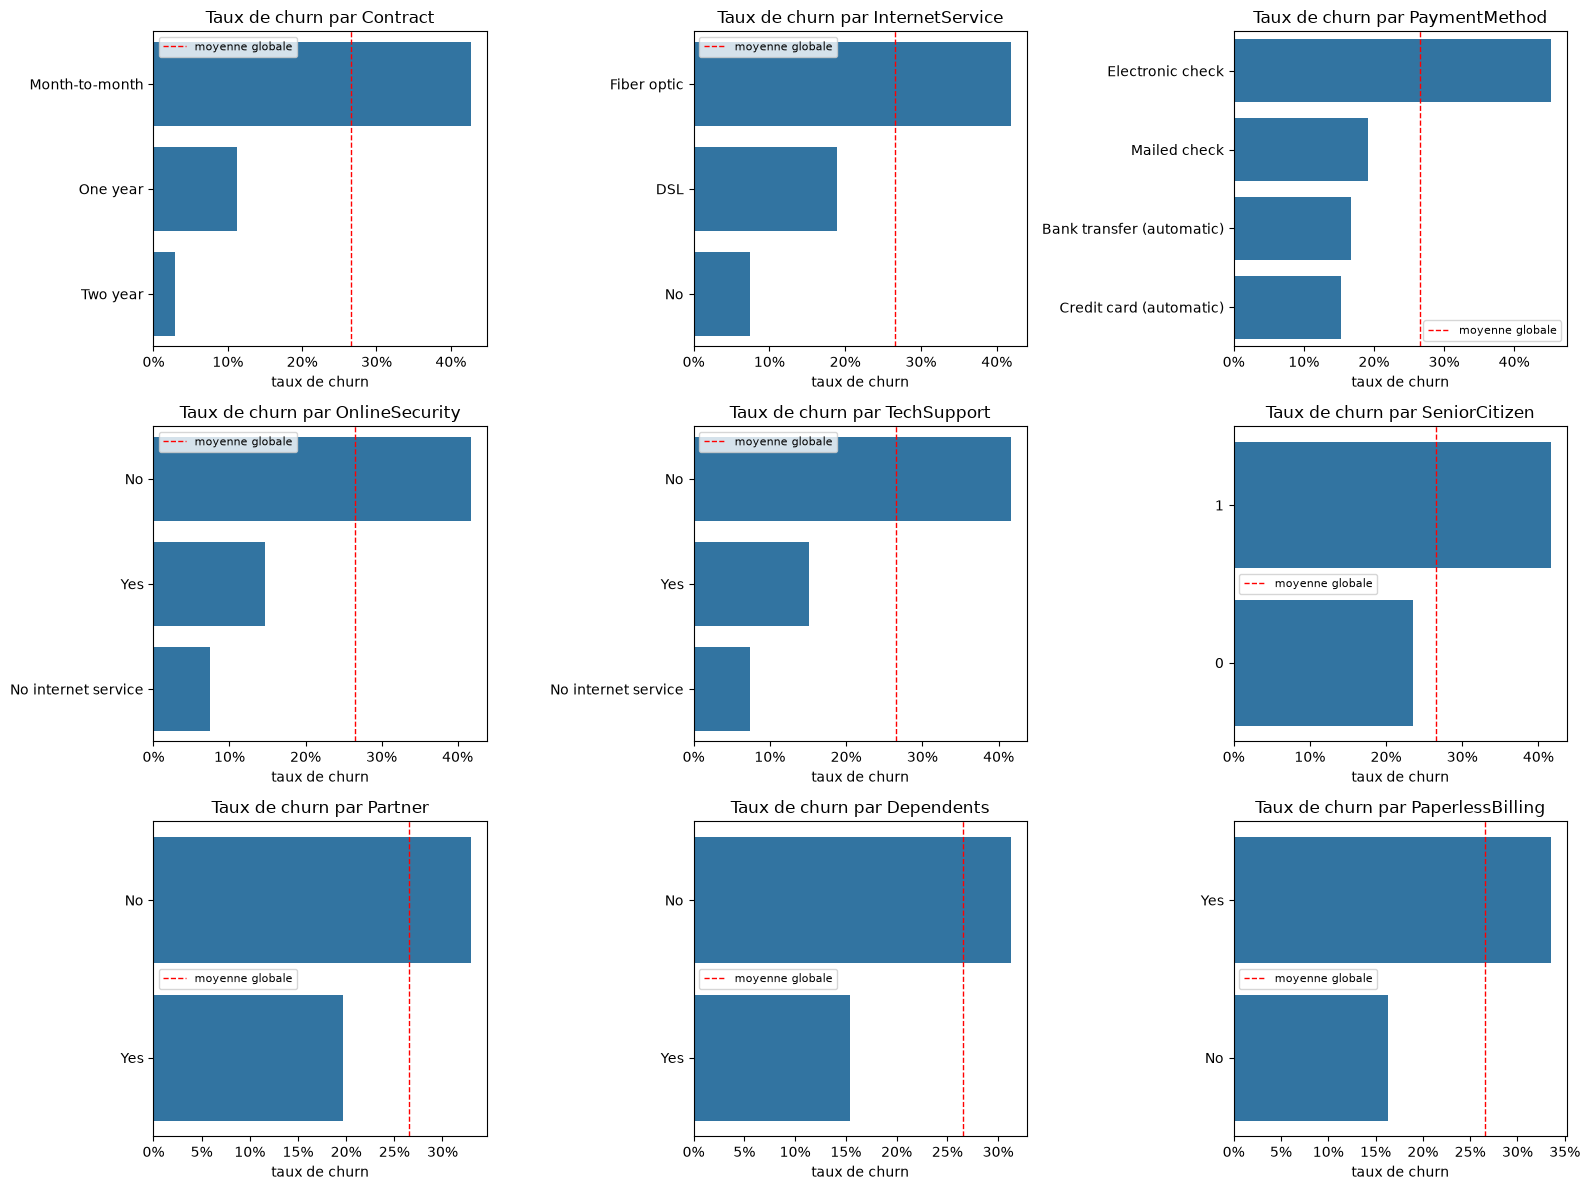

In [88]:
cat_for_churn = ["Contract", "InternetService", "PaymentMethod",
                 "OnlineSecurity", "TechSupport", "SeniorCitizen",
                 "Partner", "Dependents", "PaperlessBilling", "gender"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), cat_for_churn):
    taux_seg = df.groupby(col)["churn_binary"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=taux_seg.values, y=taux_seg.index.astype(str), ax=ax)
    ax.axvline(taux * 100, color="red", ls="--", lw=1, label="moyenne globale")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_title(f"Taux de churn par {col}")
    ax.set_xlabel("taux de churn")
    ax.set_ylabel("")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_par_categorielle.png", dpi=120)
plt.show()

### 4.3 - Churn selon le nombre de services souscrits

Variable dérivée : nombre de services réellement actifs par client (on exclut les
modalités d'absence `No` / `No phone service` / `No internet service`).
Objectif : voir si l'équipement du client est lié au risque de départ.

 nb_services    n  taux_churn
           1 1264       0.109
           2  859       0.310
           3  846       0.449
           4  965       0.365
           5  922       0.313
           6  908       0.256
           7  676       0.225
           8  395       0.124
           9  208       0.053


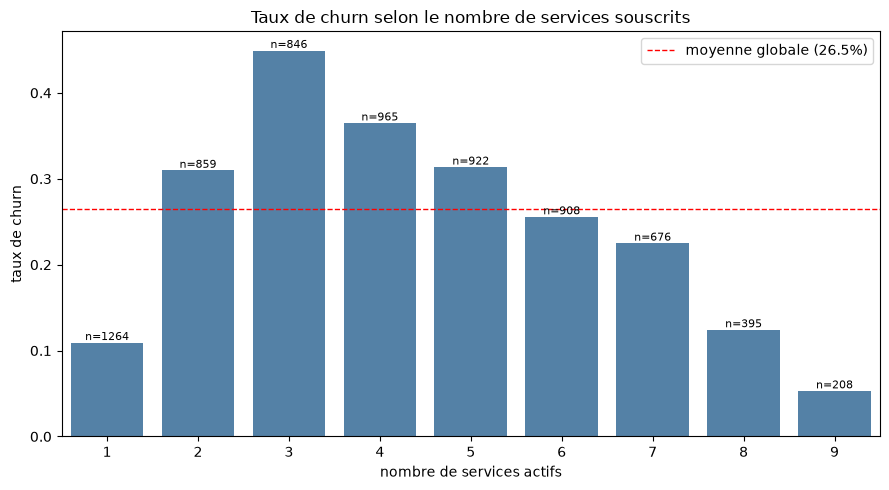

In [89]:
service_cols = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]

absent = ["No", "No phone service", "No internet service"]

df["nb_services"] = sum(
        (
            ~df[col].isin(absent)
        ).astype(int) for col in service_cols
    )

reco = df.groupby("nb_services").agg(
    n=("churn_binary", "size"),
    taux_churn=("churn_binary", "mean"),
).reset_index()
print(reco.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x="nb_services", y="churn_binary", errorbar=None, ax=ax, color="steelblue")
ax.axhline(taux, color="red", ls="--", lw=1, label=f"moyenne globale ({taux:.1%})")
ax.set_title("Taux de churn selon le nombre de services souscrits")
ax.set_xlabel("nombre de services actifs")
ax.set_ylabel("taux de churn")

for _, row in reco.iterrows():
    ax.annotate(f"n={row['n']:.0f}", (row["nb_services"] - 1, row["taux_churn"]),
                ha="center", va="bottom", fontsize=8)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_par_nb_services.png", dpi=120)
plt.show()

### 4.4 - Churn par variable numérique

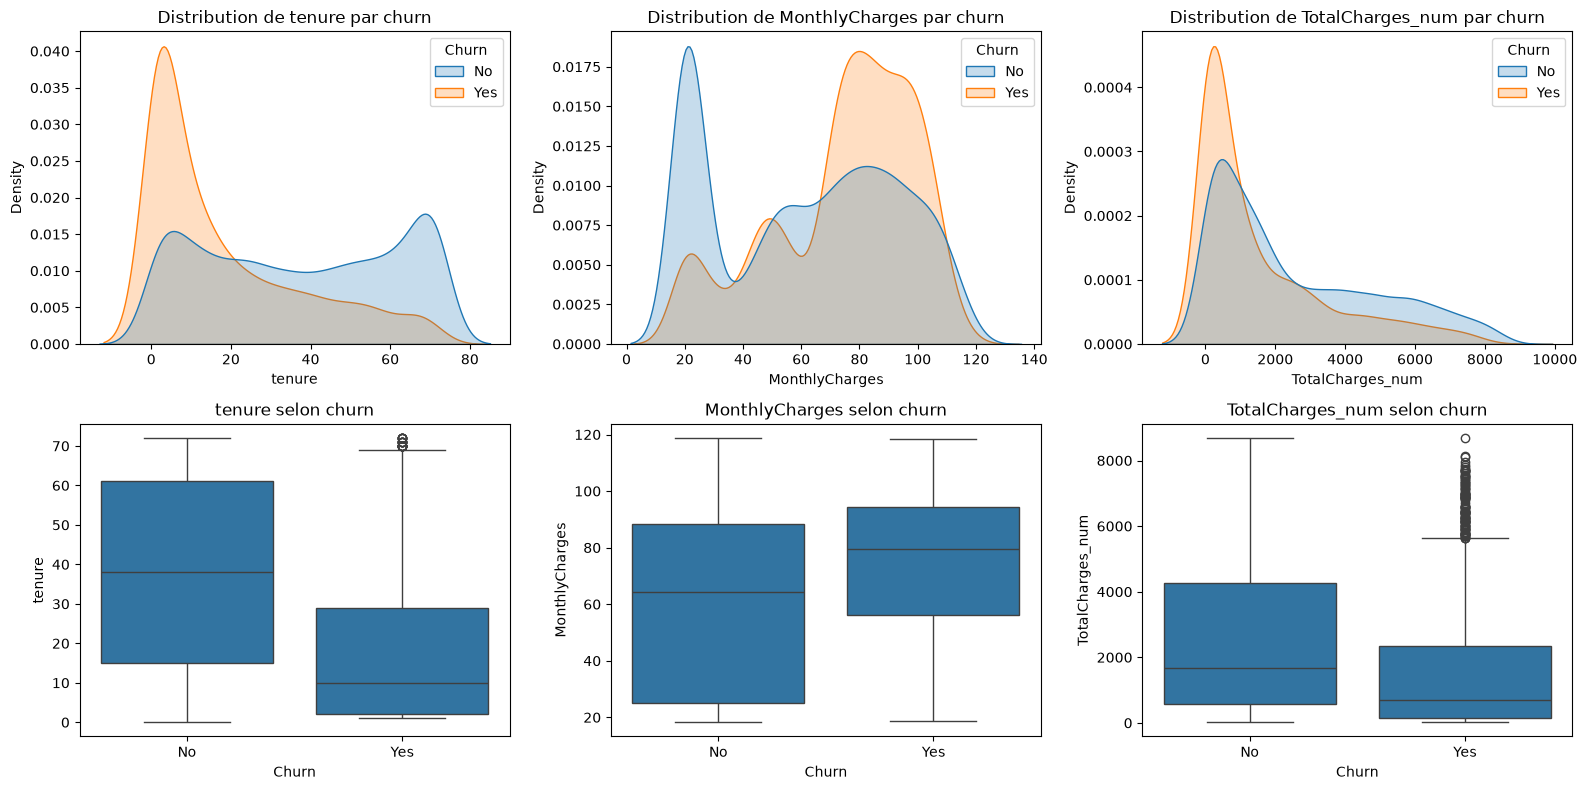

In [90]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges_num"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(num_cols):
    # Distribution par classe (KDE)
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, ax=axes[0, i])
    axes[0, i].set_title(f"Distribution de {col} par churn")
    # Boxplot par classe
    sns.boxplot(data=df, x=TARGET, y=col, order=["No", "Yes"], ax=axes[1, i])
    axes[1, i].set_title(f"{col} selon churn")
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_par_numerique.png", dpi=120)
plt.show()

### 4.5 - Corrélations entre numériques

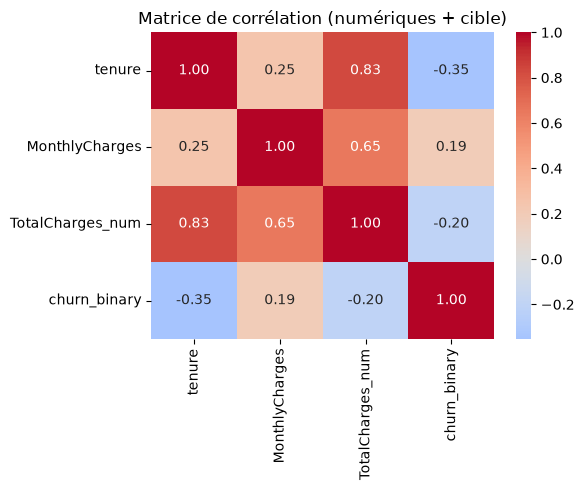

In [91]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges_num", "churn_binary"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matrice de corrélation (numériques + cible)")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlations.png", dpi=120)
plt.show()

### 4.6 - Association des variables catégorielles avec la cible (Cramér's V)

La heatmap 4.4 ne couvre que les 3 numériques (corrélation point-bisériale avec
`churn_bin`). Pour mesurer le lien des variables **catégorielles** avec le churn,
Pearson n'a pas de sens : on utilise le **Cramér's V**, dérivé du χ², qui donne une
**force d'association dans [0, 1]** (0 = indépendance, 1 = association parfaite),
valable quel que soit le nombre de modalités. On applique une correction de biais
(Bergsma-Wicher) pour ne pas surestimer les variables à nombreuses modalités.

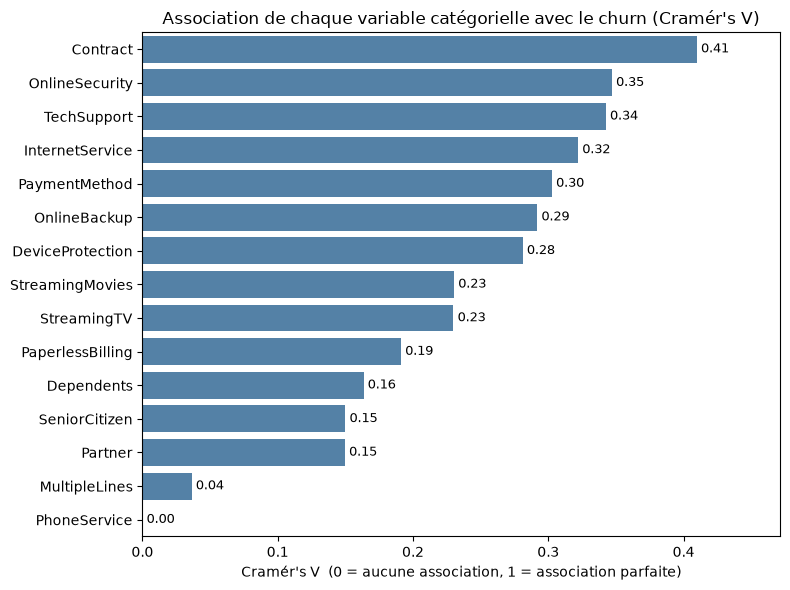

In [92]:
def cramers_v(x, y):
    """Cramér's V avec correction de biais (Bergsma-Wicher).

    Force d'association entre deux variables catégorielles, dans [0, 1].
    Non-signée : mesure l'intensité du lien, pas son sens.
    """
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))


cat_cols = [
    "Contract", "PaymentMethod", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines",
    "PhoneService", "PaperlessBilling", "SeniorCitizen", "Partner", "Dependents",
]

assoc = (pd.Series({c: cramers_v(df[c], df[TARGET]) for c in cat_cols})
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=assoc.values, y=assoc.index, color="steelblue", ax=ax)
ax.set_title("Association de chaque variable catégorielle avec le churn (Cramér's V)")
ax.set_xlabel("Cramér's V  (0 = aucune association, 1 = association parfaite)")
ax.set_ylabel("")
for i, v in enumerate(assoc.values):
    ax.annotate(f"{v:.2f}", (v, i), va="center", ha="left",
                fontsize=9, xytext=(3, 0), textcoords="offset points")
ax.set_xlim(0, assoc.max() * 1.15)
fig.tight_layout()
fig.savefig(FIG_DIR / "cramers_v_churn.png", dpi=120)
plt.show()

**Synthèse — churn par variable catégorielle**

Trois familles de facteurs ressortent, par ordre d'impact décroissant.

*1. Le contrat et la facturation dominent.*
Le type de contrat est le discriminant le plus fort : ~43 % de churn en
`Month-to-month` contre ~11 % en `One year` et ~3 % en `Two year`. L'engagement
dans la durée est le meilleur rempart anti-départ. Même logique côté paiement :
`Electronic check` décroche très au-dessus de la moyenne (~45 %), là où les
prélèvements automatiques (carte, virement) tournent autour de 15 %. La
facturation dématérialisée (`PaperlessBilling = Yes`, ~34 %) va dans le même sens
— ces variables décrivent surtout un profil de client peu engagé / récent.

*2. L'écosystème internet et les options de réassurance.*
La fibre est paradoxalement le segment le plus à risque (~42 % vs ~19 % en DSL,
~7 % sans internet) — probablement un effet prix/attentes. À l'inverse, l'absence
des options `OnlineSecurity` et `TechSupport` est fortement associée au churn
(~42 % sans, ~15 % avec) : ces services « collants » fidélisent. La modalité
`No internet service` ramène mécaniquement à ~7 %, cohérente entre toutes ces
colonnes (même socle de clients).

*3. Le profil démographique : signal réel mais secondaire.*
`SeniorCitizen = 1` (~42 %), absence de `Partner` (~33 %) et absence de
`Dependents` (~31 %) sont au-dessus de la moyenne, mais les écarts sont plus
modestes. Profil type : client seul, sans charge de famille, plus volatil.

*Variable non-informative :* `gender` — Female et Male sont quasi identiques
(~27 % chacun), collés à la moyenne globale. À écarter de la modélisation
comme prédicteur, ce que confirmera le Cramér's V (étape suivante, V ≈ 0).

**Lecture métier :** la cible de rétention prioritaire se dessine déjà — client
**fibre, en contrat mensuel, paiement par chèque électronique, sans options de
sécurité/support**. Le croisement de ces axes (Phase suivante) précisera le
ciblage sous budget.

## Section 5: Protocole d'évaluation

Règles figées ici et reprises à l'identique en Phases 2 (baseline) et 3 (finetuning).

**Split** : train/valid/test = 60/20/20, **stratifié sur `Churn`**, `random_state = RANDOM_STATE`.
Le jeu de **test n'est touché qu'à la toute fin** (estimation non biaisée de la performance).
**Validation** : `StratifiedKFold` pour le tuning d'hyperparamètres (Phase 3).

**Métriques retenues** (déséquilibre modéré ~26,5 %) :
- **ROC-AUC** — pouvoir de classement (minimum imposé par le sujet).
- **PR-AUC / average precision** — plus parlante en contexte déséquilibré.
- **recall@10 % et precision@10 %** — liées au ciblage « top K% sous budget marketing ».
- **Matrice de confusion + F1** au seuil retenu (reporting).

**Gestion du déséquilibre** : modéré → `class_weight="balanced"` (baseline) puis
ajustement du seuil par coût/bénéfice (Phase 3, ex. coût offre 15 € / valeur sauvée 120 €),
plutôt qu'un rééchantillonnage agressif.

**Anti-fuite** : toutes les transformations (imputation, encodage, scaling) seront apprises
**uniquement sur le train** via une `Pipeline` scikit-learn.

In [ ]:
y = df[TARGET]

# 60/40 puis 40 → 20/20, stratifié à chaque étape
idx_train, idx_tmp = train_test_split(
    df.index, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
idx_valid, idx_test = train_test_split(
    idx_tmp, test_size=0.5, stratify=y[idx_tmp], random_state=RANDOM_STATE
)

# Contrôle : le taux de churn doit être stable dans les 3 sous-ensembles
for name, idx in [("train", idx_train), ("valid", idx_valid), ("test", idx_test)]:
    sub = df.loc[idx]
    print(f"{name:5s} : n={len(sub):4d} ({len(sub)/len(df):.0%})  churn={sub['churn_binary'].mean():.4f}")

Index([3080, 2079, 4018, 5057, 4587, 4206, 4571,  194, 4386, 2830,
       ...
       2632, 4259, 5115, 1816, 6861, 6362, 1388, 3787, 4126,  449],
      dtype='int64', length=1409)
train : n=4225 (60%)  churn=0.2653
valid : n=1409 (20%)  churn=0.2654
test  : n=1409 (20%)  churn=0.2654


In [ ]:
# On persiste la PARTITION (IDs seulement), pas les données : le CSV brut reste la
# source de vérité unique. Les notebooks 02/03 rechargent le brut à jour et refont
# tout le preprocessing sur le train via Pipeline -> pas de désync, pas de fuite.
SPLIT_DIR = ROOT / "data" / "processed"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

for name, idx in [("train", idx_train), ("valid", idx_valid), ("test", idx_test)]:
    df.loc[idx, ["customerID"]].to_csv(SPLIT_DIR / f"split_{name}.csv", index=False)

print("Splits sauvegardés")

Splits sauvegardés
